# Exploration of COLET dataset

The original dataset from this [paper](https://doi.org/10.1016/j.cmpb.2022.106989) has a single *.mat* file containing tabular data from the experiments.

Since this format is not easy to use with *Python*, a MATLAB script was used to extract the relevant data as *.csv* files, which can be easily loaded with *Pandas* library.

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

COLET_DATASET_DIR = Path("../datasets/COLET_CSV")
EXP_SELECT = "participant_01/Task_1"

In [4]:
# Load the different daat from eye tracker
gaze_df = pd.read_csv(COLET_DATASET_DIR / EXP_SELECT / "gaze.csv")
pupil_df = pd.read_csv(COLET_DATASET_DIR / EXP_SELECT / "pupil.csv")
blink_df = pd.read_csv(COLET_DATASET_DIR / EXP_SELECT / "blinks.csv")

print(f"Loaded {gaze_df.shape[0]} gaze records:")
display(gaze_df.head(1))
print(f"Loaded {pupil_df.shape[0]} pupil records:")
display(pupil_df.head(5))
print(f"Loaded {blink_df.shape[0]} blink records:")
display(blink_df.head())

Loaded 8205 gaze records:


,gaze_timestamp,confidence,norm_pos_x,norm_pos_y,gaze_point_3d_x,gaze_point_3d_y,gaze_point_3d_z
0,5410.551715,0.999499,0.446264,0.846886,-6.72063,-31.252881,80.700682


Loaded 16406 pupil records:


,pupil_timestamp,eye_id,confidence,norm_pos_x,norm_pos_y,diameter,ellipse_center_x,ellipse_center_y,ellipse_axis_a,ellipse_axis_b
0,5410.553797,1,1.000000,0.406205,0.708513,40.757561,77.991356,55.965595,25.383852,40.757561
1,5410.553797,1,0.999646,0.406235,0.708578,40.764095,77.997212,55.953014,26.110611,40.764095
2,5410.557872,0,0.999661,0.326001,0.395972,38.729047,62.592283,115.973389,23.373748,38.729047
3,5410.557872,0,1.000000,0.325980,0.396084,38.723305,62.588215,115.951805,23.741541,38.723305
4,5410.561675,1,1.000000,0.406046,0.707954,40.842903,77.960808,56.072765,25.485304,40.842903


Loaded 2 blink records:


,id,start_timestamp,duration,end_timestamp,start_frame_index,index,end_frame_index,confidence,filter_response,base_data
0,1,5437.625617,0.236131,5437.861748,37,40,44,0.703872,0.5068225043614704 0.5512669488059149 0.595711...,5437.625617 5437.629564 5437.633621 5437.63786...
1,2,5444.161561,0.180073,5444.341634,231,233,236,0.553669,0.5048782729116744 0.5493227173561188 0.592878...,5444.161561 5444.165642 5444.169793 5444.17554...


In [5]:
# Some insights about the duration of the gaze and pupil data
gaze_start_time = gaze_df['gaze_timestamp'].min()
gaze_end_time = gaze_df['gaze_timestamp'].max()
pupil_start_time = pupil_df['pupil_timestamp'].min()
pupil_end_time = pupil_df['pupil_timestamp'].max()
print(f"Gaze data duration: {gaze_end_time - gaze_start_time} s")
print(f"Pupil data duration: {pupil_end_time - pupil_start_time} s")

print(f"Estimated gaze frequency: {gaze_df.shape[0] / (gaze_end_time - gaze_start_time):.2f} Hz")
print(f"Estimated pupil (right) frequency: {pupil_df[pupil_df.eye_id == 1].shape[0] / (pupil_end_time - pupil_start_time):.2f} Hz")
print(f"Estimated pupil (left) frequency: {pupil_df[pupil_df.eye_id == 0].shape[0] / (pupil_end_time - pupil_start_time):.2f} Hz")


Gaze data duration: 33.80600950000007 s
Pupil data duration: 33.80392700000084 s
Estimated gaze frequency: 242.71 Hz
Estimated pupil (right) frequency: 242.69 Hz
Estimated pupil (left) frequency: 242.63 Hz


It looks like they are using two methods to calculate the pupil related metrics ('2D c++' / '3D c++'). It also seems that there is always one that has a higher confidence, so the diameter will be chosen from the highest confidence value.

Also, it seems like it is always switching between left and right eye for a **combined** frequency of 240Hz

In [6]:
# Sort pupil data by choosing best confidence for each timestamp for each eye
pupil_df_best = pupil_df.groupby(['pupil_timestamp', 'eye_id'], as_index=False).apply(lambda x: x.loc[x['confidence'].idxmax()])
pupil_df_best.reset_index(drop=True, inplace=True)
pupil_df_best.drop(columns=['norm_pos_x', 'norm_pos_y'], inplace=True)
pupil_df_best.rename(columns={'diameter': 'pupil_diameter', 'confidence': 'pupil_confidence'}, inplace=True)
pupil_df_best

,pupil_timestamp,eye_id,pupil_confidence,pupil_diameter,ellipse_center_x,ellipse_center_y,ellipse_axis_a,ellipse_axis_b
0,5410.553797,1,1.000000,40.757561,77.991356,55.965595,25.383852,40.757561
1,5410.557872,0,1.000000,38.723305,62.588215,115.951805,23.741541,38.723305
2,5410.561675,1,1.000000,40.842903,77.960808,56.072765,25.485304,40.842903
3,5410.565491,0,1.000000,39.237560,62.568382,115.802177,23.588182,39.237560
4,5410.571092,1,1.000000,40.950336,77.953743,56.054668,25.205196,40.950336
...,...,...,...,...,...,...,...,...
8198,5444.341634,0,0.735939,30.008591,71.342831,105.565708,22.186894,30.008591
8199,5444.345790,1,0.045619,40.353993,58.252892,55.428499,11.294928,40.353993
8200,5444.350231,0,0.390900,41.681687,66.234522,113.613751,27.634551,41.681687
8201,5444.353666,1,0.657261,42.941853,79.710823,60.829433,27.937931,42.941853


In [7]:
# Merge gaze and pupil data on closest timestamp match
merged_df = pd.merge_asof(gaze_df.sort_values('gaze_timestamp'),
                          pupil_df_best.sort_values('pupil_timestamp'),
                          left_on='gaze_timestamp',
                          right_on='pupil_timestamp',
                          direction='nearest',
                          tolerance=1.0/240*2)  # tolerance in ms
print(f"There are {merged_df[merged_df.pupil_confidence.isna()].index.size} non matching timestamp within the limits")
# Since only one value, drop the row
merged_df_clean = merged_df.dropna()
# Let's reindex the dataframe using timestamp starting from 0 adn dropping the original timestamp columns
merged_df_clean['timestamp'] = merged_df_clean['gaze_timestamp'] - gaze_start_time
merged_df_clean.drop(columns=['gaze_timestamp', 'pupil_timestamp'], inplace=True)

There are 1 non matching timestamp within the limits


## Gaze analysis

Let's now visualize the gaze data we are working with

<Axes: title={'center': 'Gaze points in normalized coordinates'}, xlabel='norm_pos_x', ylabel='norm_pos_y'>

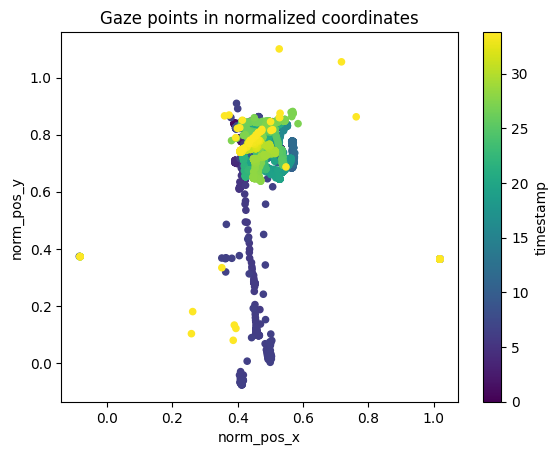

In [8]:
from matplotlib import colormaps

colormap = colormaps.get_cmap("viridis")
merged_df_clean.plot("norm_pos_x", "norm_pos_y", kind='scatter', c='timestamp', colormap=colormap, title="Gaze points in normalized coordinates")

Let's now implement the I-VT algorithm to detect fixations and saccades

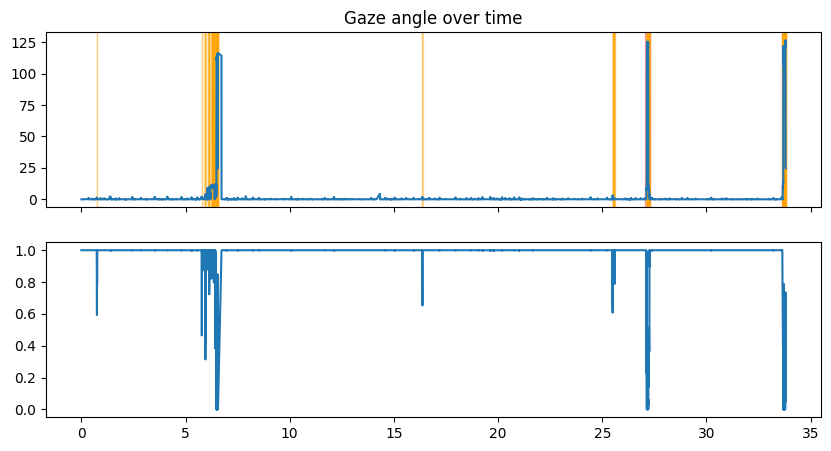

In [ ]:
# Create a dataframe with (x,y,z) from current and previous timestamp on the same rows
from matplotlib import pyplot as plt


gaze_angular_data = merged_df_clean[['timestamp', 'gaze_point_3d_x', 'gaze_point_3d_y', 'gaze_point_3d_z']].copy()
gaze_angular_data['prev_gaze_point_3d_x'] = gaze_angular_data['gaze_point_3d_x'].shift(1)
gaze_angular_data['prev_gaze_point_3d_y'] = gaze_angular_data['gaze_point_3d_y'].shift(1)
gaze_angular_data['prev_gaze_point_3d_z'] = gaze_angular_data['gaze_point_3d_z'].shift(1)
gaze_angular_data.drop(index=0, inplace=True)  # Drop the first row which has NaN values
gaze_angular_data.head()

def calculate_angle(row):
    v1 = np.array([row['gaze_point_3d_x'], row['gaze_point_3d_y'], row['gaze_point_3d_z']])
    v2 = np.array([row['prev_gaze_point_3d_x'], row['prev_gaze_point_3d_y'], row['prev_gaze_point_3d_z']])
    dot_product = np.dot(v1, v2)
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)
    if norm_v1 == 0 or norm_v2 == 0:
        return 0.0
    cos_theta = dot_product / (norm_v1 * norm_v2)
    cos_theta = np.clip(cos_theta, -1.0, 1.0)  # Clip to avoid numerical issues
    angle_rad = np.arccos(cos_theta)
    angle_deg = np.degrees(angle_rad)
    return angle_deg

gaze_angular_data['gaze_angle'] = gaze_angular_data.apply(calculate_angle, axis=1)
fig, axs = plt.subplots(2,1,figsize=(10, 5), sharex=True)
axs[0].plot(gaze_angular_data['timestamp'], gaze_angular_data['gaze_angle'])
axs[0].title.set_text("Gaze angle over time")

gaze_angular_data[gaze_angular_data.gaze_angle > 20].count()

gaze_angular_data['low_confidence'] = merged_df_clean['pupil_confidence'] < 0.95

# Let's check when are the blinks occurring in the gaze angle data
blink_df_clean = blink_df.copy()
blink_df_clean['timestamp'] = blink_df_clean['start_timestamp'] - gaze_start_time
for _, row in blink_df_clean.iterrows():
    axs[0].axvspan(row['timestamp'], row['timestamp'] + row['duration'], color='red', alpha=0.3)
# Let's mark zones with low confidence
for _, row in gaze_angular_data[gaze_angular_data.low_confidence].iterrows():
    axs[0].axvspan(row['timestamp'], row['timestamp'] + 1.0/240, color='orange', alpha=0.3)

# Let's also add the confidence level over time on the same plot
y_data = merged_df_clean[['timestamp', 'pupil_confidence']].set_index('timestamp')
axs[1].plot(y_data.index, y_data['pupil_confidence'])



Let's measure the different gaps of low confidence (to eventually label blinks)

In [63]:
low_confidence_df = merged_df_clean[['timestamp', 'pupil_confidence', 'ellipse_axis_a']].copy()
low_confidence_df['low_confidence'] = low_confidence_df['pupil_confidence'] < 0.95
low_confidence_df['transition'] = low_confidence_df['low_confidence'] != low_confidence_df['low_confidence'].shift(1)
low_confidence_df['group'] = low_confidence_df['transition'].cumsum()
low_confidence_df['id'] = low_confidence_df.index
low_confidence_df_gfoup = low_confidence_df.groupby('group').agg({'low_confidence': ['first', 'count'], 'timestamp': ['min', 'max'], 'ellipse_axis_a': ['min', 'max'], 'id': ['min', 'max']})
low_confidence_df_gfoup['duration_ms'] = (low_confidence_df_gfoup['timestamp']['max'] - low_confidence_df_gfoup['timestamp']['min']) * 1000
low_confidence_df_gfoup['openness_delta'] = low_confidence_df_gfoup['ellipse_axis_a']['max'] - low_confidence_df_gfoup['ellipse_axis_a']['min']
low_confidence_df_gfoup[low_confidence_df_gfoup['low_confidence']['first']].head()

print(f"Number of low confidence periods with a single sample: {(low_confidence_df_gfoup['low_confidence']['first'] & (low_confidence_df_gfoup['low_confidence']['count'] == 1)).sum()}")
print(f"Number of low confidence periods with a duration less than 100 ms: {(low_confidence_df_gfoup['low_confidence']['first'] & (low_confidence_df_gfoup['duration_ms'] < 100)).sum()}")
print(f"Number of possible blink candidates [100-300 ms]: {(low_confidence_df_gfoup['low_confidence']['first'] & (low_confidence_df_gfoup['duration_ms'] >= 100) & (low_confidence_df_gfoup['duration_ms'] <= 300)).sum()}")
print(f"Number of long low confidence periods (> 300 ms): {(low_confidence_df_gfoup['low_confidence']['first'] & (low_confidence_df_gfoup['duration_ms'] > 300)).sum()}")

gaps_to_fill_df = low_confidence_df_gfoup[low_confidence_df_gfoup['low_confidence']['first'] & (low_confidence_df_gfoup['duration_ms'] < 100)]
gaps_to_fill_df = gaps_to_fill_df[[('id', 'min'), ('id', 'max'), ('timestamp', 'min'), ('timestamp', 'max')]].reset_index(drop=True)
display(gaps_to_fill_df.head())

average_openness_delta_valid_samples = low_confidence_df_gfoup[(~low_confidence_df_gfoup['low_confidence']['first'])]['openness_delta'].mean()
print(f"Average openness delta for valid samples: {average_openness_delta_valid_samples:.2f} mm")
low_confidence_df_gfoup[(low_confidence_df_gfoup['low_confidence']['first'] & (low_confidence_df_gfoup['duration_ms'] >= 100) & (low_confidence_df_gfoup['duration_ms'] <= 300))]

custom_blinks_df = low_confidence_df_gfoup[(low_confidence_df_gfoup['low_confidence']['first'] & (low_confidence_df_gfoup['duration_ms'] >= 100) & (low_confidence_df_gfoup['duration_ms'] <= 300))].copy()
custom_blinks_df['start_timestamp'] = custom_blinks_df['timestamp']['min']
custom_blinks_df['stop_timestamp'] = custom_blinks_df['timestamp']['max']
custom_blinks_df['start_id'] = custom_blinks_df['id']['min']
custom_blinks_df['stop_id'] = custom_blinks_df['id']['max']
custom_blinks_df = custom_blinks_df[['start_id', 'stop_id', 'start_timestamp', 'stop_timestamp', 'duration_ms']].reset_index(drop=True)
custom_blinks_df.head()

Number of low confidence periods with a single sample: 22
Number of low confidence periods with a duration less than 100 ms: 36
Number of possible blink candidates [100-300 ms]: 3
Number of long low confidence periods (> 300 ms): 0


id       timestamp          
    min   max       min       max
0   186   186  0.749889  0.749889
1   188   188  0.755894  0.755894
2  1422  1423  5.777089  5.781952
3  1454  1454  5.904703  5.904703
4  1463  1463  5.941953  5.941953

Average openness delta for valid samples: 2.61 mm


,start_id,stop_id,start_timestamp,stop_timestamp,duration_ms
,,,,,
0,1587,1616,6.442226,6.558011,115.7850
1,6551,6581,27.138213,27.260122,121.9085
2,8163,8204,33.644225,33.806010,161.7845


Let's try to interpolate missing values

Also let's truncate the end because the particiapnt was probably moving away from the screen, making the data erronous (not meaningful anyway)

In [ ]:
from scipy.interpolate import interp1d
def interpolate_missing_gaze(eye_data_df, gaps_df, N=100):
    if 'gaze_angle_delta_deg' not in eye_data_df.columns:
        raise ValueError("eye_data_df must contain 'gaze_angle_delta_deg' column")
    if 'pupil_diameter_mm' not in eye_data_df.columns:
        raise ValueError("eye_data_df must contain 'pupil_diameter_mm' column")
    
    if 'start_id' not in gaps_df.columns or 'stop_id' not in gaps_df.columns:
        raise ValueError("gaps_df must contain 'start_id' and 'stop_id' columns")
    
    eye_data_df = eye_data_df.copy()
    eye_data_df['interpolated'] = False
    
    for _, gap in gaps_df.iterrows():
        start_id = gap['start_id']
        stop_id = gap['stop_id']
        
        if start_id < 0 or stop_id >= len(eye_data_df):
            print(f"Skipping invalid gap with start_id {start_id} and stop_id {stop_id}")
            continue

        # Check if window around the data fits within the dataframe
        window_start = max(0, start_id - N // 2)
        window_end = min(len(eye_data_df) - 1, stop_id + N // 2)
        if window_end - window_start < N:
            print(f"Skipping gap with insufficient data around start_id {start_id} and stop_id {stop_id}")
            continue

        # Make sure there is not other gap inside the window
        if ((gaps_df['start_id'] >= window_start) & (gaps_df['start_id'] <= window_end)).any() or ((gaps_df['stop_id'] >= window_start) & (gaps_df['stop_id'] <= window_end)).any():
            print(f"Skipping gap with overlapping gap inside the window around start_id {start_id} and stop_id {stop_id}")
            continue
        
        x = eye_data_df.loc[window_start:window_end, 'timestamp']
        y_angle = eye_data_df.loc[window_start:window_end, 'gaze_angle_delta_deg']
        y_pupil = eye_data_df.loc[window_start:window_end, 'pupil_diameter_mm']
        
        # Create interpolation functions
        interp_angle = interp1d(x, y_angle, kind='linear', fill_value="extrapolate")
        interp_pupil = interp1d(x, y_pupil, kind='linear', fill_value="extrapolate")
        
        # Interpolate values for the gap
        gap_timestamps = eye_data_df.loc[start_id:stop_id, 'timestamp']
        interpolated_angles = interp_angle(gap_timestamps)
        interpolated_pupils = interp_pupil(gap_timestamps)
        
        # Fill in the interpolated values
        eye_data_df.loc[start_id:stop_id, 'gaze_angle_delta_deg'] = interpolated_angles
        eye_data_df.loc[start_id:stop_id, 'pupil_diameter_mm'] = interpolated_pupils
        eye_data_df.loc[start_id:stop_id, 'interpolated'] = True

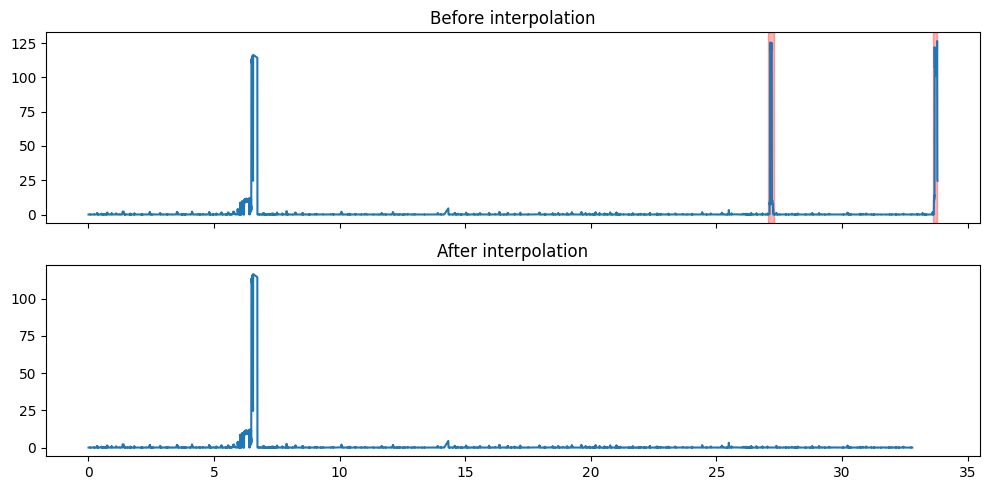

In [ ]:
def interpolate_blinks(gaze_df, blink_start, blink_end, N=200):
    # Only use the data before the blink, as it was a realtime window
    pre_blink_data = gaze_df[gaze_df['timestamp'] < blink_start].tail(N // 2)
    post_blink_data = gaze_df[gaze_df['timestamp'] > blink_end].head(N // 2)
    if pre_blink_data.empty or post_blink_data.empty:
        return None  # Not enough data to interpolate
    # Combine pre and post blink data for interpolation
    combined_data = pd.concat([pre_blink_data, post_blink_data])
    x = combined_data['timestamp']
    y = combined_data['gaze_angle']
    # Create interpolation function
    from scipy.interpolate import interp1d
    interp_func = interp1d(x, y, kind='linear')
    M = int((blink_end - blink_start) * 240)  # Number of points to interpolate based on sampling rate
    interpolated_timestamps = np.linspace(blink_start, blink_end, M)
    interpolated_angles = interp_func(interpolated_timestamps)
    interpolated_df = pd.DataFrame({
        'timestamp': interpolated_timestamps,
        'gaze_angle': interpolated_angles,
        'interpolated': True
    })
    return pd.concat([gaze_df[gaze_df['timestamp'] < blink_start], interpolated_df, gaze_df[gaze_df['timestamp'] > blink_end]]).sort_values('timestamp').reset_index(drop=True)

filtered_gaze_angular_df = gaze_angular_data.iloc[:-250]
filtered_gaze_angular_df['interpolated'] = False
filtered_gaze_angular_df = interpolate_blinks(filtered_gaze_angular_df, blink_df_clean.iloc[0]['timestamp'], blink_df_clean.iloc[0]['timestamp'] + blink_df_clean.iloc[0]['duration'])
fig, axs = plt.subplots(2, 1, figsize=(10, 5), tight_layout=True, sharex=True)
axs[0].plot(gaze_angular_data['timestamp'], gaze_angular_data['gaze_angle'])
axs[0].title.set_text("Before interpolation")
for _, row in blink_df_clean.iterrows():
    axs[0].axvspan(row['timestamp'], row['timestamp'] + row['duration'], color='red', alpha=0.3)

axs[1].plot(filtered_gaze_angular_df['timestamp'], filtered_gaze_angular_df['gaze_angle'])
axs[1].title.set_text("After interpolation")


Then, there is still the case of some outliars where validity is low

56


ValueError: Cannot mask with non-boolean array containing NA / NaN values

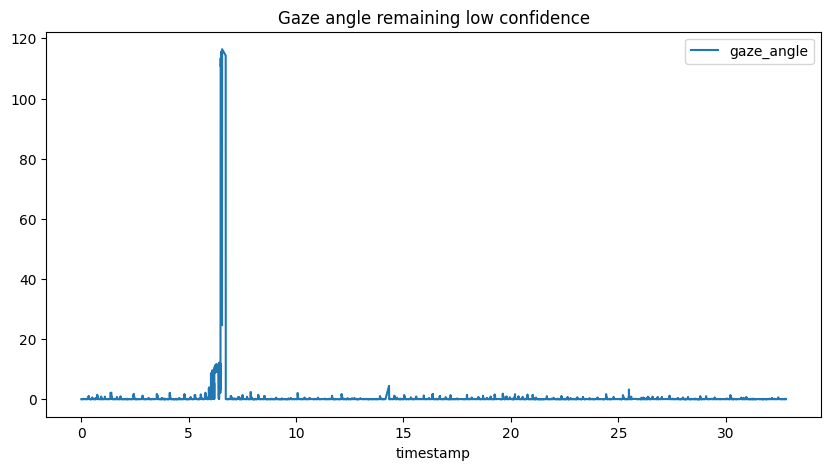

In [11]:
# Interpolate low confidence zones were less than N consecutive points with low confidence
N = 5
def interpolate_low_confidence_zones(df, N=10):
    df = df.copy()
    df['low_confidence_group'] = ((df['angular_velocity'] > 1000) != (df['angular_velocity'] > 1000).shift(1) ).cumsum()
    for group, group_df in df.groupby('low_confidence_group'):
        if group_df['angular_velocity'].iloc[0] > 1000 and len(group_df) <= N:
            # Interpolate this low confidence zone
            start_idx = group_df.index[0] - 1
            end_idx = group_df.index[-1] + 1
            if start_idx >= df.index[0] and end_idx < df.index[-1]:
                start_angle = df.loc[start_idx, 'gaze_angle']
                end_angle = df.loc[end_idx, 'gaze_angle']
                interpolated_angles = np.linspace(start_angle, end_angle, len(group_df) + 2)[1:-1]
                df.loc[group_df.index, 'gaze_angle'] = interpolated_angles
        elif group_df['angular_velocity'].iloc[0] > 1000:
            # Drop this low confidence zone
            df.drop(index=group_df.index, inplace=True)
    return df.drop(columns=['low_confidence_group']).reset_index(drop=True)

print(filtered_gaze_angular_df['interpolated'].sum())
ax = filtered_gaze_angular_df.plot("timestamp", "gaze_angle", kind='line', title="Gaze angle remaining low confidence", figsize=(10, 5))
for _, row in filtered_gaze_angular_df[filtered_gaze_angular_df['low_confidence']].iterrows():
    ax.axvspan(row['timestamp'], row['timestamp'] + 1.0/240, color='red', alpha=0.3)

<Axes: title={'center': 'Gaze angle over time with blinks and low confidence zones (interpolated)'}, xlabel='timestamp'>

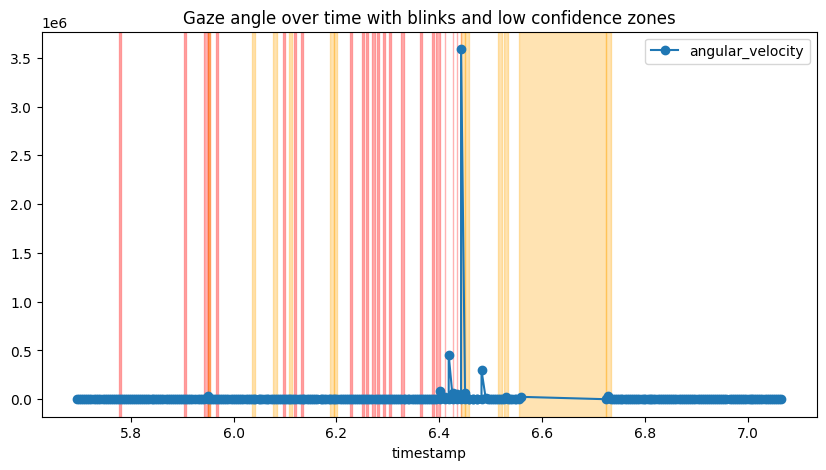

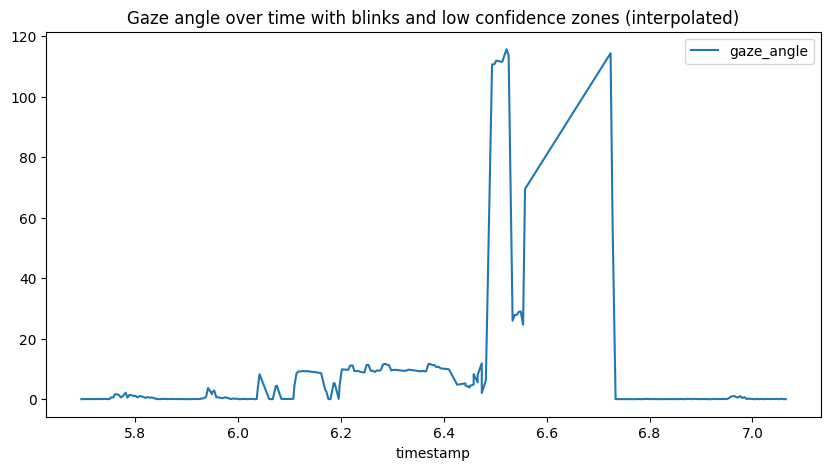

In [12]:
def calculate_angular_velocity(row, absolute=True):
    if pd.isna(row['prev_gaze_angle']):
        return 0.0
    delta_angle = row['gaze_angle'] - row['prev_gaze_angle']
    delta_time = row['delta_time']
    if delta_time == 0:
        return 0.0
    angular_velocity = delta_angle / delta_time
    return abs(angular_velocity) if absolute else angular_velocity

low_confidence_rm_df = filtered_gaze_angular_df.copy()[1400:1700]
low_confidence_rm_df['prev_gaze_angle'] = low_confidence_rm_df['gaze_angle'].shift(1)
low_confidence_rm_df['delta_time'] = low_confidence_rm_df['timestamp'] - low_confidence_rm_df['timestamp'].shift(1)
low_confidence_rm_df['angular_velocity'] = low_confidence_rm_df.apply(calculate_angular_velocity, axis=1)
ax = low_confidence_rm_df.plot("timestamp", "angular_velocity", title="Gaze angle over time with blinks and low confidence zones", figsize=(10, 5), marker='o')
low_confidence_rm_df['transition'] = low_confidence_rm_df['low_confidence'] != low_confidence_rm_df['low_confidence'].shift(1)
for idx in low_confidence_rm_df[low_confidence_rm_df['transition']].index:
    if low_confidence_rm_df.loc[idx, 'low_confidence']:
        ax.axvspan(low_confidence_rm_df.loc[idx, 'timestamp'], low_confidence_rm_df.loc[idx + 1, 'timestamp'], color='red', alpha=0.3)

# Interpolate datapoints in low confidence zones if there are less than N consecutive low confidence points, otherwise drop them
N = 1
def interpolate_low_confidence_zones(df, N=10):
    df = df.copy()
    df['low_confidence_group'] = ((df['angular_velocity'] > 1000) != (df['angular_velocity'] > 1000).shift(1) ).cumsum()
    for group, group_df in df.groupby('low_confidence_group'):
        if group_df['angular_velocity'].iloc[0] > 1000 and len(group_df) <= N:
            # Interpolate this low confidence zone
            start_idx = group_df.index[0] - 1
            end_idx = group_df.index[-1] + 1
            if start_idx >= df.index[0] and end_idx < df.index[-1]:
                ax.axvspan(df.loc[start_idx, 'timestamp'], df.loc[end_idx, 'timestamp'], color='orange', alpha=0.3)
                start_angle = df.loc[start_idx, 'gaze_angle']
                end_angle = df.loc[end_idx, 'gaze_angle']
                interpolated_angles = np.linspace(start_angle, end_angle, len(group_df) + 2)[1:-1]
                df.loc[group_df.index, 'gaze_angle'] = interpolated_angles
        elif group_df['angular_velocity'].iloc[0] > 1000:
            # Drop this low confidence zone
            df.drop(index=group_df.index, inplace=True)
    return df.drop(columns=['low_confidence_group']).reset_index(drop=True)

low_confidence_rm_df_interpolated = interpolate_low_confidence_zones(low_confidence_rm_df, N=N)
low_confidence_rm_df_interpolated.plot("timestamp", "gaze_angle", title="Gaze angle over time with blinks and low confidence zones (interpolated)", figsize=(10, 5))


# Lets implement a low pass 5 point FIR filter to smooth the angular velocity signal
# def low_pass_fir_filter(data, N=5):
#     kernel = np.ones(N) / N
#     return np.convolve(data, kernel, mode='same')

# low_confidence_rm_df['angular_velocity_smooth'] = low_pass_fir_filter(low_confidence_rm_df['angular_velocity'])
# low_confidence_rm_df.plot("timestamp", "angular_velocity_smooth", title="Smoothed gaze angular velocity over time with blinks and low confidence zones", figsize=(10, 5))

In [13]:
(gaze_df['gaze_timestamp'] - gaze_df['gaze_timestamp'].shift(1)).describe()

count    8204.000000
mean        0.004121
std         0.003694
min         0.000000
25%         0.003903
50%         0.003997
75%         0.004091
max         0.183988
Name: gaze_timestamp, dtype: float64

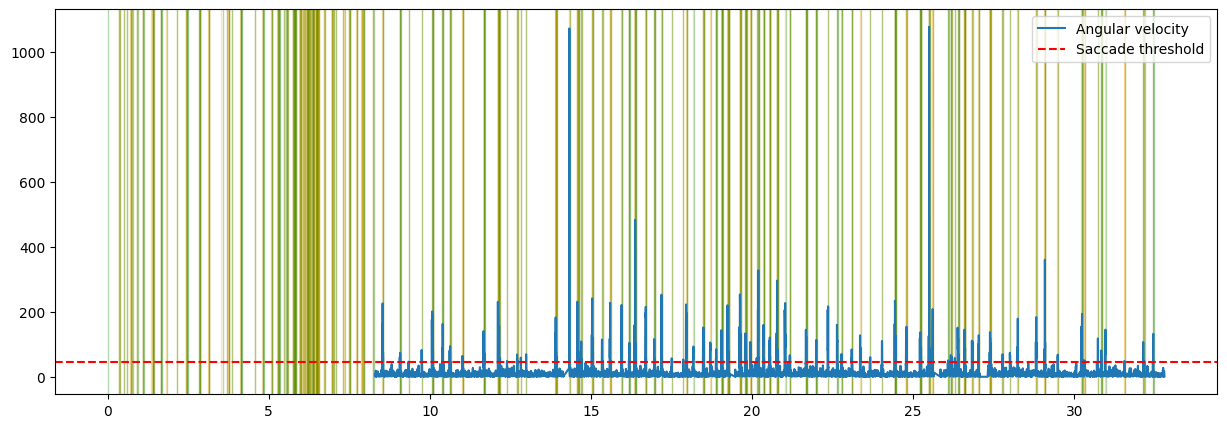

In [ ]:
VELOCITY_THRESH = 45

filtered_gaze_angular_df['prev_gaze_angle'] = filtered_gaze_angular_df['gaze_angle'].shift(1)
filtered_gaze_angular_df['delta_time'] = filtered_gaze_angular_df['timestamp'] - filtered_gaze_angular_df['timestamp'].shift(1)
filtered_gaze_angular_df['angular_velocity'] = filtered_gaze_angular_df.apply(calculate_angular_velocity, axis=1)
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(filtered_gaze_angular_df[2000:]['timestamp'], filtered_gaze_angular_df[2000:]['angular_velocity'], label='Angular velocity')
ax.axhline(VELOCITY_THRESH, color='red', linestyle='--', label='Saccade threshold')
ax.legend()

# Let's mark the zones for saccades and fixations based on the angular velocity
filtered_gaze_angular_df['saccade'] = filtered_gaze_angular_df['angular_velocity'] > VELOCITY_THRESH
filtered_gaze_angular_df['fixation'] = ~filtered_gaze_angular_df['saccade']
# Identify transitions between saccades and fixations
filtered_gaze_angular_df['transition'] = filtered_gaze_angular_df['saccade'] != filtered_gaze_angular_df['saccade'].shift(1)
for idx in filtered_gaze_angular_df[filtered_gaze_angular_df['transition']].index:
    if filtered_gaze_angular_df.loc[idx, 'saccade']:
        ax.axvspan(filtered_gaze_angular_df.loc[idx, 'timestamp'], filtered_gaze_angular_df.loc[idx+1, 'timestamp'], color='orange', alpha=0.3)
    else:
        ax.axvspan(filtered_gaze_angular_df.loc[idx, 'timestamp'], filtered_gaze_angular_df.loc[idx+1, 'timestamp'], color='green', alpha=0.3)
